In [254]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.table import QTable
import astropy.units as u
import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib import colors

In [ ]:
## ctrl / to uncomment the following for animation package

# from matplotlib import pyplot as plt, animation
# %matplotlib inline
# # This is needed to display graphics calculated outside of jupyter notebook
# from IPython.display import HTML, display
# # Also, in case we haven't created it yet, make sure that we have a directory for images and videos
# ! test -d ../images/Python_Animation && rm -rf ../images/Python_Animation/* || mkdir -p ../images/Python_Animation

In [331]:
# import CLM2 history files
File_land = "/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ_psg.001/lnd/hist/b.e21.BWma1850.f19_g17.new_circ_psg.001.clm2.h0.0014-04.nc" #file name
DataSet_land = xr.open_dataset(File_land) #open the file
File_CAM = "/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/atm/hist/b.e21.BWma1850.f19_g17.new_circ.001.cam.h0.0002-03.nc" #file name
DataSet_CAM = xr.open_dataset(File_CAM) #open the file

# creating land/ocean mask
# we can only assign a new coord to the data set (main), but not the data array(variables)
# we should truncate the very large orginal .nc file into smaller .nc file with requried variables
# to save the Jupyter notebook memory and allow it to run (hint: ncrcat)
DataSet_CAM = xr.open_dataset(File_CAM) #open the file
DataSet_CAM.coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)

In [72]:
# Auto file input
var_flux=["SOLIN",
         "FLNT",
         "FSNT",
         "FSUTOA"]       #  +["FSNS","FLNS","FLDS","FLUT"]
var_clearsky=["FLNTC",
             "FSNTC"]    #  +["FSNSC","FLUTC"]

var_state=["T",
          "TS",
          "ICEFRAC"]     #  +["ASDIR","ASDIF"]

var_cloud=["CLDTOT",
          "CLDLOW",
          "CLDHGH",
          "CLOUD",
          "CLDICE",
          "SWCF",
          "LWCF",
          "TGCLDLWP"]
var_precip=["PRECC",
           "PRECL",
           "TMQ",
           "LHFLX"]
var_dynamic=["VT",
            "VQ"]

output_var=var_flux+var_clearsky+var_state+var_cloud+var_precip+var_dynamic

data_directory = ['/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/atm/hist/',
                '/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_test.001/atm/hist/']

filepath=[[],[]]

e_range=["_circ","_e4"]


for i in range(len(data_directory)):  
    if i==0:  
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j]+ e_range[i] +'_obl0.nc') 
            ds_circ=xr.merge([xr.open_mfdataset(filepath[i])])
    if i==1:
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j] +'_merge.nc')
            ds_e4=xr.merge([xr.open_mfdataset(filepath[i])])

In [7]:
def weighted_temporal_mean(ds, var):
    """
    weight by days in each month
    """
    # Determine the month length
    month_length = ds.time.dt.days_in_month
    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)
    # Subset our dataset for our variable
    obs = ds[var]
    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)
    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="AS").sum(dim="time")
    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="AS").sum(dim="time")
    # Return the weighted average
    return obs_sum / ones_out


def weighted_annual_mean(ds):
    month_length=T_circ[0].T.sel(time=slice('0012-01', '0012-12')).time.dt.days_in_month
    month_length=month_length.groupby("time.month").sum()
    weights_month = month_length/365
    np.testing.assert_allclose(weights_month.sum().values, np.ones(1))
    ds_weighted = (ds["var"]*weights_month).sum()d
    return ds_weighted

# note for weighted_annual_mean(ds):
# This function may be used when there is variable to call in the data array
# But you need to do something like the following:
# F=B+D
# F['var'] = (['month'], F.values)

In [141]:
# plotting functions

# annual mean2D lat&lon 
def latlon2D(ds,var_name,timeslice):
    output=weighted_temporal_mean(ds.sel(time=timeslice),var_name).mean(dim='time')
    return output
# annual mean2D lat&lon, monthly mean function
def latlon2D_month(dsvar,timeslice,month):
    output=dsvar.sel(time=timeslice).groupby('time.month').mean(dim='time').sel(month=month)
    return output

# line plot

# zonal mean 2D time x-axis

# global mean vertical 2D time x-axis

In [303]:
# plotting functions

def plot_latlon2D(x,title,colorbar_label,**kwargs):

    vmin = kwargs.get('vmin', None)
    vmax = kwargs.get('vmax', None)
    unit_converter = kwargs.get('unit_converter', None)
    colormap = kwargs.get('colormap', None)
    discrete_num=kwargs.get('discrete_num', None)    
    
    gs = gridspec.GridSpec(2, 1)
    plt.figure(figsize=(11,15))
    plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

    ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
    ax.set_global() 
    ax.coastlines()
    fg=(x*unit_converter).plot(cmap=colormap,transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,levels=discrete_num)
    plt.tick_params(labelsize=20)
    plt.minorticks_on()
    fg.colorbar.ax.tick_params(labelsize=15)
    fg.colorbar.set_label(label=colorbar_label, size=15)
    if discrete_num==3:
        fg.colorbar.set_ticklabels(["<30 cm/yr",">30 cm/yr"])
        fg.colorbar.set_ticks([0, 1])
    if discrete_num==13:
        fg.colorbar.set_ticks(list(range(0,13,1)))

    plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
    plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
    plt.title(title,fontsize=15)

    return(fg)

In [225]:
print(list(range(0,2)))

[0, 1]


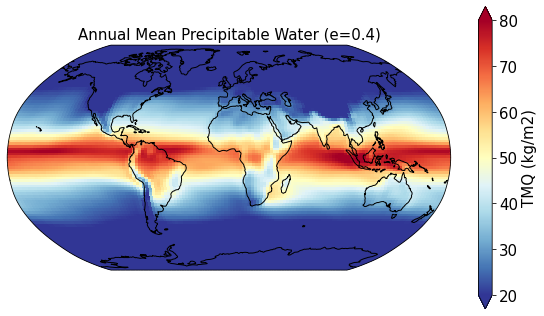

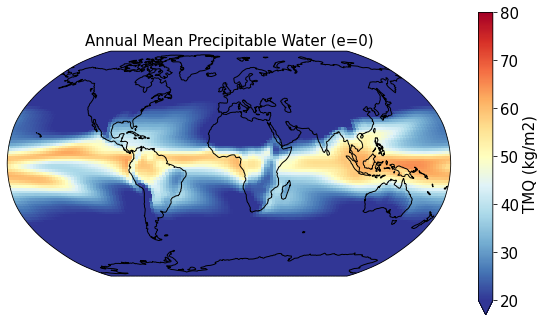

In [193]:
# precipitable water for annual mean

plot_latlon2D(latlon2D(ds_e4,"TMQ",timeslice=slice('0016-01', '0020-12')),title='Annual Mean Precipitable Water (e=0.4)',
              colorbar_label="TMQ"+" "+"("+ds_e4.TMQ.attrs["units"]+")",
            vmin=20,vmax=80,
             colormap='RdYlBu_r',
             unit_converter=1)

plot_latlon2D(latlon2D(ds_circ,"TMQ",timeslice=slice('0016-01', '0020-12')),title='Annual Mean Precipitable Water (e=0)',
              colorbar_label="TMQ"+" "+"("+ds_e4.TMQ.attrs["units"]+")",
             vmin=20,vmax=80,
             colormap='RdYlBu_r',
             unit_converter=1)

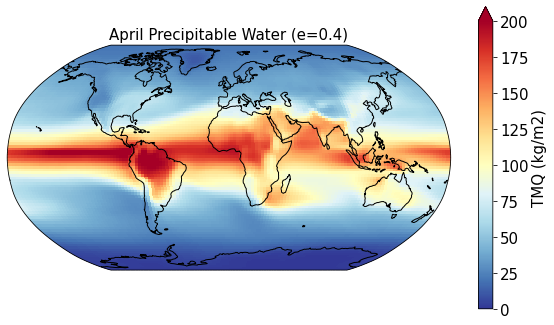

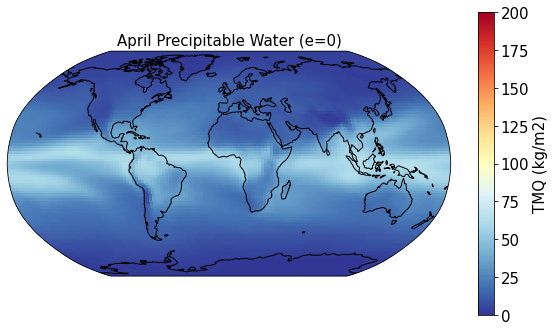

In [194]:
# precipitable water for a specified month

plot_latlon2D(latlon2D_month(ds_e4.TMQ,timeslice=slice('0016-01', '0020-12'),month=4),title='April Precipitable Water (e=0.4)',
              colorbar_label="TMQ"+" "+"("+ds_e4.TMQ.attrs["units"]+")",
             vmin=0,vmax=200,
            colormap='RdYlBu_r',
             unit_converter=1)

plot_latlon2D(latlon2D_month(ds_circ.TMQ,timeslice=slice('0016-01', '0020-12'),month=4),title='April Precipitable Water (e=0)',
              colorbar_label="TMQ"+" "+"("+ds_e4.TMQ.attrs["units"]+")",
             vmin=0,vmax=200,
             colormap='RdYlBu_r',
             unit_converter=1)


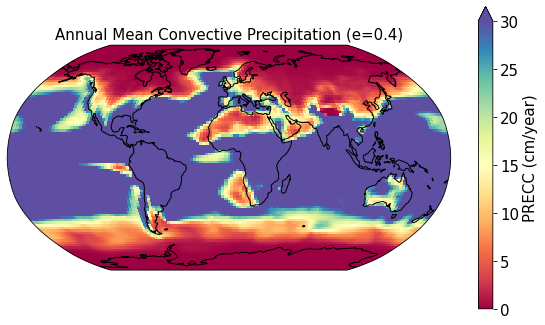

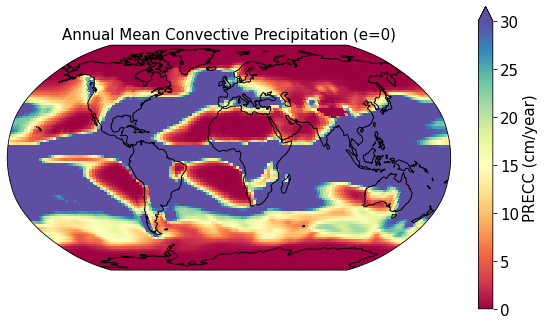

In [170]:
# Convective precipitation for annual mean

unit_converter=365*24*3600*100  # from m/s to cm/yr

plot_latlon2D(latlon2D(ds_e4,"PRECC",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Convective Precipitation (e=0.4)',
              colorbar_label="PRECC"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

plot_latlon2D(latlon2D(ds_circ,"PRECC",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Convective Precipitation (e=0)',
              colorbar_label="PRECC"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

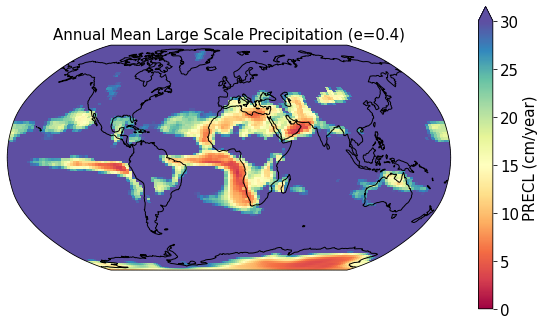

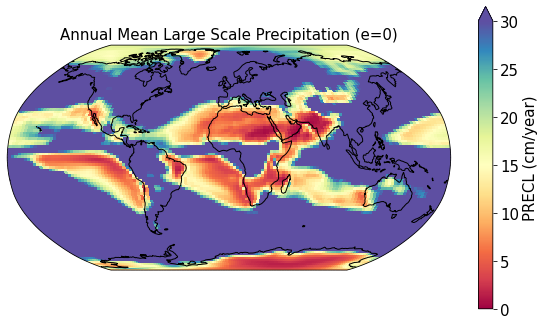

In [169]:
# Large Scale precipitation for annual mean

unit_converter=365*24*3600*100  # from m/s to cm/yr

plot_latlon2D(latlon2D(ds_e4,"PRECL",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Large Scale Precipitation (e=0.4)',
              colorbar_label="PRECL"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

plot_latlon2D(latlon2D(ds_circ,"PRECL",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Large Scale Precipitation (e=0)',
              colorbar_label="PRECL"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

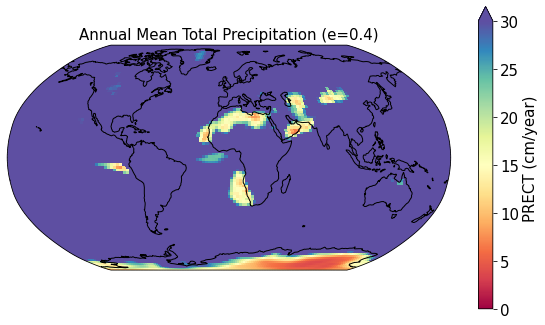

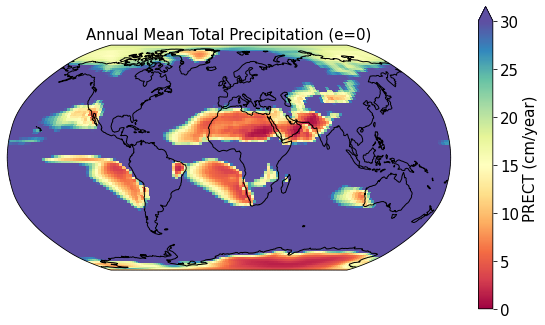

In [217]:
# total precipitation for annual mean

ds_circ['PRECT'] = (ds_circ.PRECC+ds_circ.PRECL)
ds_circ['PRECT'].attrs["long_name"]="Total Precipitation"
ds_circ['PRECT'].attrs["units"]="m/s"
ds_circ['PRECT'].attrs["cell_methods"]="time:mean"

ds_e4['PRECT'] = (ds_e4.PRECC+ds_e4.PRECL)
ds_e4['PRECT'].attrs["long_name"]="Total Precipitation"
ds_e4['PRECT'].attrs["units"]="m/s"
ds_e4['PRECT'].attrs["cell_methods"]="time:mean"

plot_latlon2D(latlon2D(ds_e4,"PRECT",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Total Precipitation (e=0.4)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

plot_latlon2D(latlon2D(ds_circ,"PRECT",timeslice=slice('0016-01', '0020-12')),title='Annual Accumulative Total Precipitation (e=0)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')


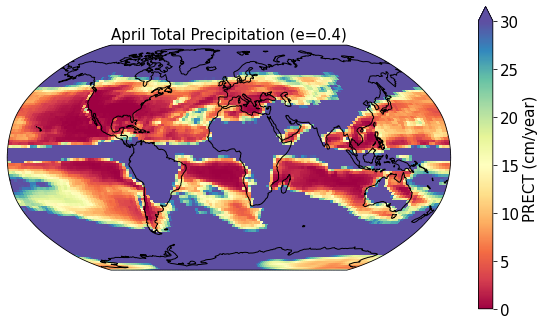

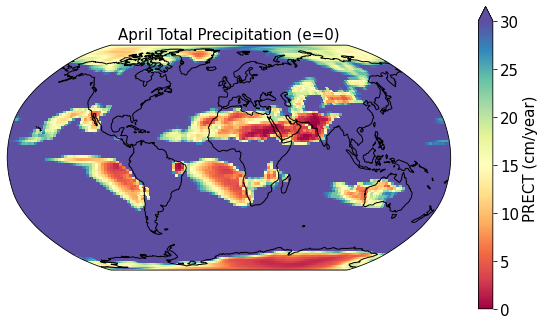

In [197]:
plot_latlon2D(latlon2D_month(ds_e4.PRECT,timeslice=slice('0016-01', '0020-12'),month=4),title='April Total Precipitation (e=0.4)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')

plot_latlon2D(latlon2D_month(ds_circ.PRECT,timeslice=slice('0016-01', '0020-12'),month=4),title='April Total Precipitation (e=0)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=unit_converter,
              vmin=0,vmax=30,
             colormap='Spectral')


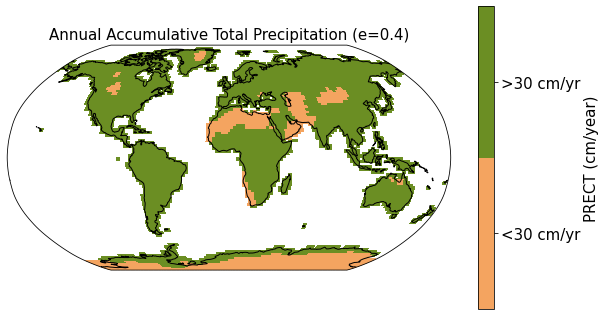

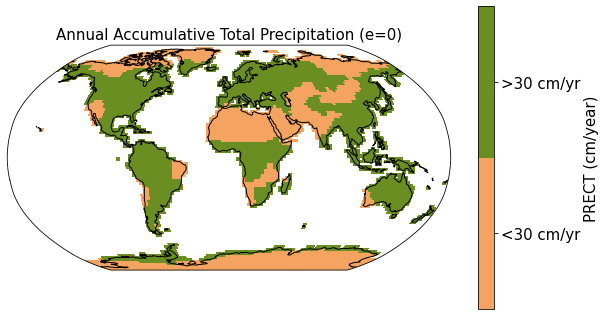

In [294]:
PRECT_circ=latlon2D(ds_circ,"PRECT",timeslice=slice('0016-01', '0020-12'))*unit_converter
PRECT_e4  =latlon2D(ds_e4,"PRECT",timeslice=slice('0016-01', '0020-12'))*unit_converter

# 1 for land regions where >30 cm precipitation

binary_map_circ=np.logical_not(np.isnan((PRECT_circ/PRECT_circ).where(PRECT_circ>30))).where(DataSet_CAM.mask == 1)
binary_map_e4  =np.logical_not(np.isnan((PRECT_e4/PRECT_e4).where(PRECT_e4>30))).where(DataSet_CAM.mask == 1)

plot_latlon2D(binary_map_e4,title='Annual Accumulative Total Precipitation (e=0.4)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=1,
              discrete_num=3,
              vmin=-0.5,vmax=1.5,
             colormap=colors.ListedColormap(['sandybrown', 'olivedrab']))

plot_latlon2D(binary_map_circ,title='Annual Accumulative Total Precipitation (e=0)',
              colorbar_label="PRECT"+" "+"("+"cm/year"+")",
             unit_converter=1,
             discrete_num=3,
              vmin=-0.5,vmax=1.5,
             colormap=colors.ListedColormap(['sandybrown', 'olivedrab']))

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


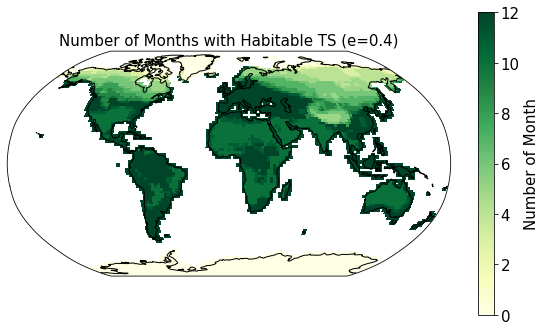

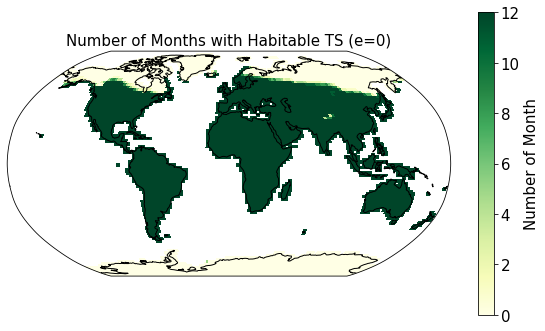

In [324]:
#
TS_Hab_e4=(ds_e4.TS/ds_e4.TS).where((ds_e4.TS>273) & (ds_e4.TS<323)).groupby('time.month').mean(dim='time').sum(dim='month').where(DataSet_CAM.mask == 1)

TS_Hab_circ=(ds_circ.TS/ds_circ.TS).where((ds_circ.TS>273) & (ds_circ.TS<323)).groupby('time.month').mean(dim='time').sum(dim='month').where(DataSet_CAM.mask == 1)

#

plot_latlon2D(TS_Hab_e4,title='Number of Months with Habitable TS (e=0.4)',
              colorbar_label="Number of Month",
             unit_converter=1,
             colormap='YlGn')

plot_latlon2D(TS_Hab_circ,title='Number of Months with Habitable TS (e=0)',
              colorbar_label="Number of Month",
             unit_converter=1,
             colormap='YlGn')

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


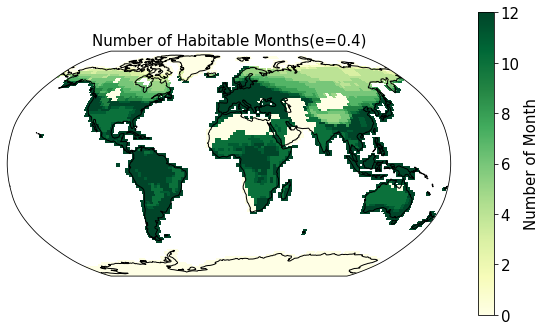

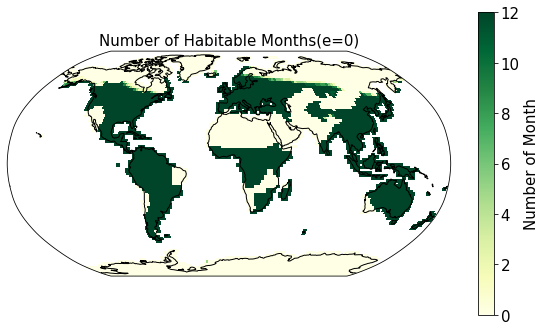

In [323]:
# Number of Habitable months with suitable precipitation and TS

N_Hab_e4  =TS_Hab_e4*binary_map_e4 
N_Hab_circ=TS_Hab_circ*binary_map_circ

plot_latlon2D(N_Hab_e4,title='Number of Habitable Months(e=0.4)',
              colorbar_label="Number of Month",
             unit_converter=1,
             colormap='YlGn')

plot_latlon2D(N_Hab_circ,title='Number of Habitable Months(e=0)',
              colorbar_label="Number of Month",
             unit_converter=1,
             colormap='YlGn')

In [344]:
N_Hab_e4  =TS_Hab_e4*binary_map_e4 
N_Hab_circ=TS_Hab_circ*binary_map_circ

ds_circ.coords['mask_Hab'] = (('lat', 'lon'), N_Hab_circ)
ds_e4.coords['mask_Hab'] = (('lat', 'lon'), N_Hab_e4)

AREA_tot      = DataSet_CAM.AREA[0,:,:].where(DataSet_CAM.mask == 1).sum()

# DataSet_CAM.AREA[0,:,:].where(ds_e4.mask_Hab > 0).plot()
# plt.figure()
# DataSet_CAM.AREA[0,:,:].where(ds_circ.mask_Hab > 0).plot()

print(DataSet_CAM.AREA[0,:,:].where(ds_e4.mask_Hab >=1).sum().values/AREA_tot)
print(DataSet_CAM.AREA[0,:,:].where(ds_circ.mask_Hab >=1).sum().values/AREA_tot)

Frac_Hab_e4   =[]
Frac_Hab_circ =[]


for i in range(1,13):
    
    Frac_Hab_e4.append(DataSet_CAM.AREA[0,:,:].where(ds_e4.mask_Hab >=i).sum().values/AREA_tot)
    Frac_Hab_circ.append(DataSet_CAM.AREA[0,:,:].where(ds_circ.mask_Hab >=i).sum().values/AREA_tot)
    


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


<xarray.DataArray 'AREA' ()>
array(0.7815292, dtype=float32)
Coordinates:
    time     object 0002-04-01 00:00:00
<xarray.DataArray 'AREA' ()>
array(0.5633396, dtype=float32)
Coordinates:
    time     object 0002-04-01 00:00:00


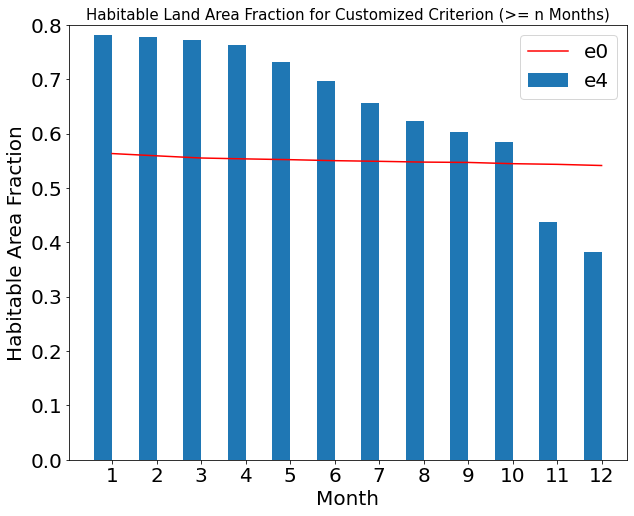

In [366]:
plt.figure(figsize=(10,8))
X = range(1,13)

e4 = Frac_Hab_e4
e0 = Frac_Hab_circ
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, e4, 0.4,label = 'e4')
plt.plot(X_axis, e0,color='red',label = 'e0')
  
plt.xticks(X_axis, X)
plt.ylim(0,0.8)
plt.xlabel("Month",fontsize=20)
plt.ylabel("Habitable Area Fraction",fontsize=20)
plt.title("Habitable Land Area Fraction for Customized Criterion (>= n Months)",fontsize=15)
plt.tick_params(labelsize=20)
plt.legend(fontsize=20)
plt.show()

In [ ]:
# # habitable if  range(1,13) months out of 1 year 


# clim_hab_e4=((PRECT_e4_index)*TS_e4_index)

# clim_hab_circ=((PRECT_circ_index)*TS_circ_index)
# clim_e4=[]

# clim_circ=[]

# for i in range(1,13):
#     clim_e4.append(clim_hab_e4.where(clim_hab_e4>=i))
    
#     clim_circ.append(clim_hab_circ.where(clim_hab_circ>=i))
    




In [ ]:
# tas=clim_e4

# # Get a handle on the figure and the axes
# fig, ax = plt.subplots(figsize=(12,6))

# ax = plt.axes(projection=ccrs.Robinson())
# ax.set_global()
# ax.coastlines()

# # Plot the initial frame

# mesh =tas[0].plot(
#     ax=ax,
#     add_colorbar=True,
# #     cmap='coolwarm',
# #     vmin=210, vmax=320,
#     transform=ccrs.PlateCarree(),
#     cbar_kwargs={
#         'extend':'neither'
#     }
# )


# def animate(t):
#     tas[t].plot(
#     ax=ax,
#     add_colorbar=False,
# #     cmap='coolwarm',
#     transform=ccrs.PlateCarree(),
# )

# ani = animation.FuncAnimation(fig, animate, 12, interval=500, blit=False)

# #ani.save('animation.gif', writer='imagemagick', fps = 2) #Save animation as gif-file

# HTML(ani.to_jshtml()) #Show the animation in the kernel


In [ ]:


# # land surface for controlled experiment

# land_TS_circ    = [TS_circ[0].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=('lat','lon')),
#                         TS_circ[1].TS.where(DataSet_CAM.mask == 1).weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=('lat','lon'))]

# annual_mean_land_TS_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_land_TS_circ[i].append(np.nanmean(land_TS_circ[i][ii*12:(ii+1)*12]))
        
# # # water surface

# water_TS_circ    = [TS_circ[0].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=('lat','lon')),
#                         TS_circ[1].TS.where(DataSet_CAM.mask != 1).weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=('lat','lon'))]


# annual_mean_water_TS_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_water_TS_circ[i].append(np.nanmean(water_TS_circ[i][ii*12:(ii+1)*12]))
        
# # # global (land+water)

# global_TS_circ    = [TS_circ[0].TS.weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=('lat','lon')),
#                          TS_circ[1].TS.weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=('lat','lon'))]



# annual_mean_global_TS_circ=[[],[]]

# for i in range(2):
#     for ii in range(14):
#         annual_mean_global_TS_circ[i].append(np.nanmean(global_TS_circ[i][ii*12:(ii+1)*12]))
        
        

In [ ]:
# TS_lnd_e0=weighted_temporal_mean(TS_circ[0].where(DataSet_CAM.mask == 1).sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon"))

# TS_lnd_e04=weighted_temporal_mean(TS_circ[1].where(DataSet_CAM.mask == 1).sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon"))

# TS_ocn_e0=weighted_temporal_mean(TS_circ[0].where(DataSet_CAM.mask != 1).sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon"))

# TS_ocn_e04=weighted_temporal_mean(TS_circ[1].where(DataSet_CAM.mask != 1).sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon"))

# TS_glb_e0=weighted_temporal_mean(TS_circ[0].sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon"))

# TS_glb_e04=weighted_temporal_mean(TS_circ[1].sel(time=slice('0002-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon"))



# TS_lnd_e0.plot(label='lnd,e0')
# TS_lnd_e04.plot(label='lnd,e04')
# TS_ocn_e0.plot(label='ocn,e0')
# TS_ocn_e04.plot(label='ocn,e04')
# TS_glb_e0.plot(label='glb,e0')
# TS_glb_e04.plot(label='glb,e04')

# plt.legend()

In [ ]:
# TS_lnd_e0_avg=weighted_temporal_mean(TS_circ[0].where(DataSet_CAM.mask == 1).sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')

# TS_lnd_e04_avg=weighted_temporal_mean(TS_circ[1].where(DataSet_CAM.mask == 1).sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')

# TS_ocn_e0_avg=weighted_temporal_mean(TS_circ[0].where(DataSet_CAM.mask != 1).sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')

# TS_ocn_e04_avg=weighted_temporal_mean(TS_circ[1].where(DataSet_CAM.mask != 1).sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')

# TS_glb_e0_avg=weighted_temporal_mean(TS_circ[0].sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[0].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')

# TS_glb_e04_avg=weighted_temporal_mean(TS_circ[1].sel(time=slice('0010-01', '0014-12')),"TS").weighted(np.cos(np.deg2rad(TS_circ[1].TS.lat))).mean(dim=("lat","lon")).mean(dim='time')


# print("%.2f" %TS_lnd_e0_avg.values)
# print("%.2f" %TS_lnd_e04_avg.values)
# print("%.2f" %TS_ocn_e0_avg.values)
# print("%.2f" %TS_ocn_e04_avg.values)
# print("%.2f" %TS_glb_e0_avg.values)
# print("%.2f" %TS_glb_e04_avg.values)

In [ ]:
# a = np.array(["lnd", "ocn", "glb"])
# b = [283.2 , 290.8, 288.1]
# c = [285.6, 292.2, 289.8]
# t = QTable([a, b, c],
#            names=('Surface Type', 'TS (e=0) [K]', 'TS (e=0.4) [K]'),
#            meta={'name': 'first table'})
# print(t)